In [1]:
import numpy as np
import pandas as pd
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix
from sklearn.manifold import TSNE
from sklearn.svm import LinearSVC
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import GridSearchCV

c:\Users\Ananya\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df=pd.read_csv("ds3.csv.zip",compression="zip")

In [3]:
df.sample(5)

,title,text,subject,date,type,label
5245,Democrat Corey Booker Backs Single-Payer and W...,This is why we cannot do deals with Democrats ...,Government News,"Sep 12, 2017",fake,0
30382,REPORT: Sean Spicer Forces Staffers To Surren...,Donald Trump s paranoia and desperation to kee...,News,"February 26, 2017",fake,0
1326,"Youngstown, Ohio, mayor gets probation in corr...","CLEVELAND (Reuters) - The mayor of Youngstown,...",politicsNews,"March 28, 2016",real,1
16586,LEGENDARY ACTOR KURT RUSSELL Hammers Anti-Gun ...,A Hollywood actor defending the 2nd Amendment ...,left-news,"Dec 10, 2015",fake,0
22456,LIBERALS SEE THE LIGHT! HuffPo Columnist LETS ...,,politics,"Dec 31, 2016",fake,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   type     44898 non-null  object
 5   label    44898 non-null  int64 
dtypes: int64(1), object(5)
memory usage: 2.1+ MB


In [5]:
df.duplicated().sum()

np.int64(209)

In [6]:
import re
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]
    return " ".join(words)

In [7]:
df["text"]=df["title"]+","+df["title"]

In [8]:
df['clean_text'] = df['text'].apply(preprocess)

In [9]:
df = df.drop(columns=["type"]).drop_duplicates()

In [10]:
df.head()

,title,text,subject,date,label,clean_text
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,BREAKING: GOP Chairman Grassley Has Had Enoug...,News,"July 21, 2017",0,breaking gop chairman grassley enough demand t...
1,Failed GOP Candidates Remembered In Hilarious...,Failed GOP Candidates Remembered In Hilarious...,News,"May 7, 2016",0,failed gop candidate remembered hilarious mock...
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,News,"December 3, 2016",0,mike pences new dc neighbor hilariously trolli...
3,California AG pledges to defend birth control ...,California AG pledges to defend birth control ...,politicsNews,"October 6, 2017",1,california ag pledge defend birth control insu...
4,AZ RANCHERS Living On US-Mexico Border Destroy...,AZ RANCHERS Living On US-Mexico Border Destroy...,politics,"Apr 25, 2017",0,az rancher living usmexico border destroy nanc...


In [11]:
df.shape

(44661, 6)

In [12]:
df["subject"].value_counts()

subject
politicsNews       11211
worldnews           9977
News                9050
politics            6835
left-news           4457
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64

In [13]:
pd.crosstab(df['subject'], df['label'])

label,0,1
subject,,
Government News,1570,0
Middle-east,778,0
News,9050,0
US_News,783,0
left-news,4457,0
politics,6835,0
politicsNews,0,11211
worldnews,0,9977


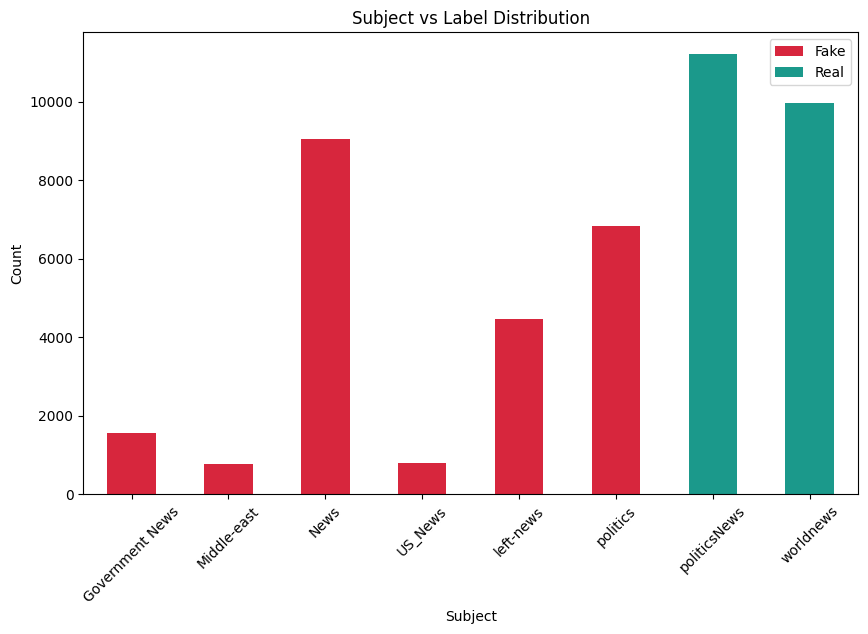

In [14]:
subject_label = pd.crosstab(df['subject'], df['label'])

subject_label.plot(kind='bar', stacked=True, figsize=(10,6), color=['#D7263D', '#1B998B'])

plt.xlabel('Subject')
plt.ylabel('Count')
plt.title('Subject vs Label Distribution')
plt.xticks(rotation=45)
plt.legend(['Fake', 'Real'])
plt.show()

In [15]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df['subject'], df['label'])
chi2, p, dof, expected = chi2_contingency(table)
print("p-value:", p)

p-value: 0.0


In [16]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.day_name()

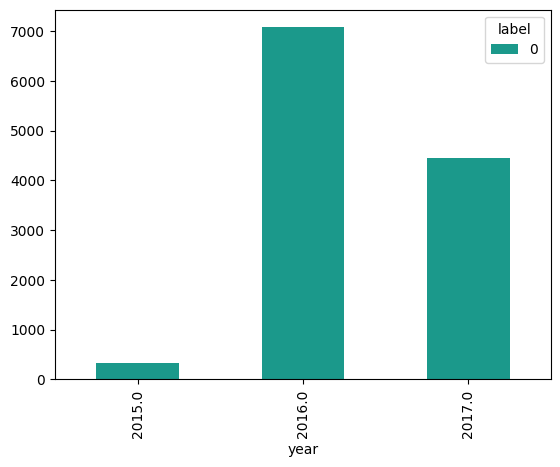

In [17]:
pd.crosstab(df['year'], df['label']).plot(kind='bar',color=['#1B998B'])
plt.show()

In [18]:
pd.crosstab(df['year'], df['label'])

label,0
year,
2015.0,338
2016.0,7077
2017.0,4449


In [19]:
X = df["clean_text"]
y = df['label']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [21]:
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1,3),min_df=2, max_df=0.95)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [22]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(35728, 50000)
(8933, 50000)


In [23]:
params = {'C':[0.1,1,5,10]}
grid = GridSearchCV(LogisticRegression(max_iter=5000), params, cv=5, scoring='f1')
grid.fit(X_train_tfidf, y_train)
print(grid.best_params_)

{'C': 10}


In [24]:
lr = LogisticRegression(C=10, max_iter=5000, solver='liblinear')

lr.fit(X_train_tfidf, y_train)
pred_lr = lr.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, pred_lr))
print(classification_report(y_test, pred_lr))

Accuracy: 0.9519758199932833
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      4695
           1       0.95      0.95      0.95      4238

    accuracy                           0.95      8933
   macro avg       0.95      0.95      0.95      8933
weighted avg       0.95      0.95      0.95      8933



In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", round(accuracy_score(y_test, pred_lr)*100,2))
print("Precision:", round(precision_score(y_test, pred_lr, average='weighted')*100,3))
print("Recall   :", round(recall_score(y_test, pred_lr, average='weighted')*100,3))
print("F1-score :", round(f1_score(y_test, pred_lr, average='weighted')*100,3))

Accuracy : 95.2
Precision: 95.197
Recall   : 95.198
F1-score : 95.197


In [26]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

rf.fit(X_train_tfidf, y_train)
pred_rf = rf.predict(X_test_tfidf)
print("Accuracy:",accuracy_score(y_test, pred_rf))
print(classification_report(y_test, pred_rf))

Accuracy: 0.9476099854472182
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      4695
           1       0.94      0.95      0.95      4238

    accuracy                           0.95      8933
   macro avg       0.95      0.95      0.95      8933
weighted avg       0.95      0.95      0.95      8933



In [31]:
print("Accuracy :", round(accuracy_score(y_test, pred_rf)*100,3))
print("Precision:", round(precision_score(y_test, pred_rf, average='weighted')*100,3))
print("Recall   :", round(recall_score(y_test, pred_rf, average='weighted')*100,3))
print("F1-score :", round(f1_score(y_test, pred_rf, average='weighted')*100,3))

Accuracy : 94.761
Precision: 94.772
Recall   : 94.761
F1-score : 94.763


In [32]:
svm = LinearSVC(C=1)
svm.fit(X_train_tfidf, y_train)
pred_svm = svm.predict(X_test_tfidf)
print("Accuracy:",accuracy_score(y_test, pred_svm))
print(classification_report(y_test, pred_svm))

Accuracy: 0.9510802641889623
              precision    recall  f1-score   support

           0       0.96      0.95      0.95      4695
           1       0.95      0.95      0.95      4238

    accuracy                           0.95      8933
   macro avg       0.95      0.95      0.95      8933
weighted avg       0.95      0.95      0.95      8933



In [33]:
print("Accuracy :", round(accuracy_score(y_test, pred_svm)*100,2))
print("Precision:", round(precision_score(y_test, pred_svm, average='weighted')*100,2))
print("Recall   :", round(recall_score(y_test, pred_svm, average='weighted')*100,2))
print("F1-score :", round(f1_score(y_test, pred_svm, average='weighted')*100,2))

Accuracy : 95.11
Precision: 95.11
Recall   : 95.11
F1-score : 95.11


In [34]:
xgb = XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=6, random_state=42)

xgb.fit(X_train_tfidf, y_train)
pred_xgb = xgb.predict(X_test_tfidf)

print("Accuracy:",accuracy_score(y_test, pred_xgb))
print(classification_report(y_test, pred_xgb))

Accuracy: 0.90675025187507
              precision    recall  f1-score   support

           0       0.96      0.86      0.91      4695
           1       0.86      0.96      0.91      4238

    accuracy                           0.91      8933
   macro avg       0.91      0.91      0.91      8933
weighted avg       0.91      0.91      0.91      8933



In [35]:
print("Accuracy :", round(accuracy_score(y_test, pred_xgb)*100,2))
print("Precision:", round(precision_score(y_test, pred_xgb, average='weighted')*100,2))
print("Recall   :", round(recall_score(y_test, pred_xgb, average='weighted')*100,2))
print("F1-score :", round(f1_score(y_test, pred_xgb, average='weighted')*100,2))

Accuracy : 90.68
Precision: 91.26
Recall   : 90.68
F1-score : 90.67


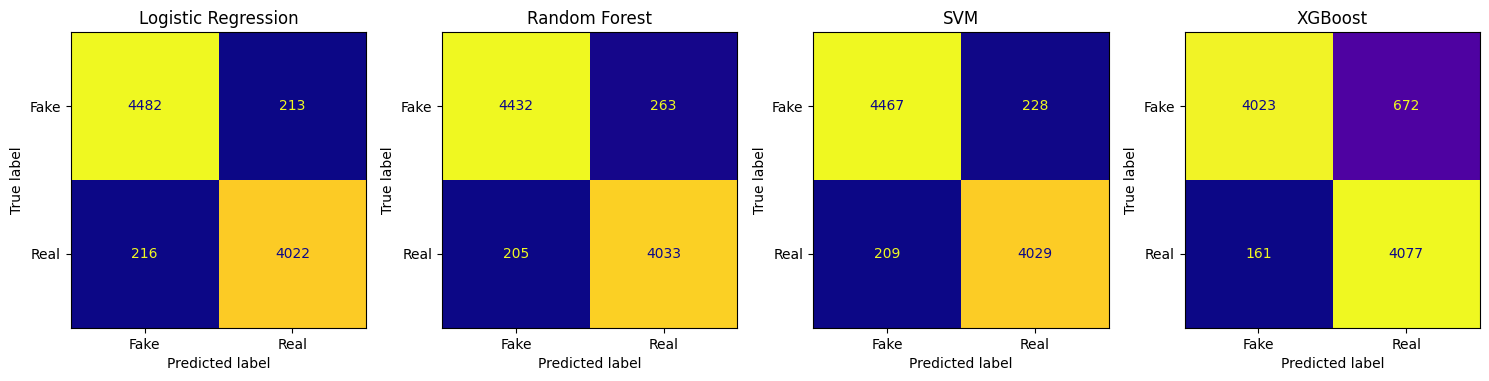

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay
models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "SVM": svm,
    "XGBoost": xgb
}

fig, axes = plt.subplots(1, len(models), figsize=(15,5))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_tfidf)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Fake', 'Real']
    )

    disp.plot(ax=ax, cmap='plasma', colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [36]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(df['clean_text'].tolist(), show_progress_bar=True)

Batches: 100%|██████████| 1396/1396 [02:14<00:00, 10.36it/s]


In [37]:
print(embeddings.shape)

(44661, 384)


In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    embeddings, df['label'], test_size=0.2, random_state=42, stratify=df['label'])

In [40]:
lr = LogisticRegression(max_iter=5000)

lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

In [41]:
print("Accuracy:", accuracy_score(y_test, pred_lr))
print(classification_report(y_test, pred_lr))

Accuracy: 0.9155938654427404
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      4695
           1       0.91      0.91      0.91      4238

    accuracy                           0.92      8933
   macro avg       0.92      0.92      0.92      8933
weighted avg       0.92      0.92      0.92      8933



In [42]:
print("Accuracy :", round(accuracy_score(y_test, pred_lr)*100,2))
print("Precision:", round(precision_score(y_test, pred_lr, average='weighted')*100,2))
print("Recall   :", round(recall_score(y_test, pred_lr, average='weighted')*100,2))
print("F1-score :", round(f1_score(y_test, pred_lr, average='weighted')*100,2))

Accuracy : 91.56
Precision: 91.56
Recall   : 91.56
F1-score : 91.56


In [43]:
xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred_xgb))
print(classification_report(y_test, pred_xgb))

Accuracy: 0.9407813724392701
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      4695
           1       0.94      0.94      0.94      4238

    accuracy                           0.94      8933
   macro avg       0.94      0.94      0.94      8933
weighted avg       0.94      0.94      0.94      8933



In [44]:
print("Accuracy :", round(accuracy_score(y_test, pred_xgb)*100,2))
print("Precision:", round(precision_score(y_test, pred_xgb, average='weighted')*100,2))
print("Recall   :", round(recall_score(y_test, pred_xgb, average='weighted')*100,2))
print("F1-score :", round(f1_score(y_test, pred_xgb, average='weighted')*100,2))

Accuracy : 94.08
Precision: 94.08
Recall   : 94.08
F1-score : 94.08


In [45]:
rf = RandomForestClassifier(n_estimators=300, random_state=42)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred_rf))
print(classification_report(y_test, pred_rf))

Accuracy: 0.9158177543938206
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      4695
           1       0.91      0.91      0.91      4238

    accuracy                           0.92      8933
   macro avg       0.92      0.92      0.92      8933
weighted avg       0.92      0.92      0.92      8933



In [46]:
print("Accuracy :", round(accuracy_score(y_test, pred_rf)*100,2))
print("Precision:", round(precision_score(y_test, pred_rf, average='weighted')*100,2))
print("Recall   :", round(recall_score(y_test, pred_rf, average='weighted')*100,2))
print("F1-score :", round(f1_score(y_test, pred_rf, average='weighted')*100,2))

Accuracy : 91.58
Precision: 91.58
Recall   : 91.58
F1-score : 91.58


In [47]:
svm = LinearSVC(C=1)
svm.fit(X_train, y_train)
pred_svm=svm.predict(X_test)
print("Accuracy:",accuracy_score(y_test, pred_svm))
print(classification_report(y_test, pred_svm))

Accuracy: 0.9229822008283891
              precision    recall  f1-score   support

           0       0.93      0.92      0.93      4695
           1       0.92      0.92      0.92      4238

    accuracy                           0.92      8933
   macro avg       0.92      0.92      0.92      8933
weighted avg       0.92      0.92      0.92      8933



In [48]:
print("Accuracy :", round(accuracy_score(y_test, pred_svm)*100,2))
print("Precision:", round(precision_score(y_test, pred_svm, average='weighted')*100,2))
print("Recall   :", round(recall_score(y_test, pred_svm, average='weighted')*100,2))
print("F1-score :", round(f1_score(y_test, pred_svm, average='weighted')*100,2))

Accuracy : 92.3
Precision: 92.3
Recall   : 92.3
F1-score : 92.3


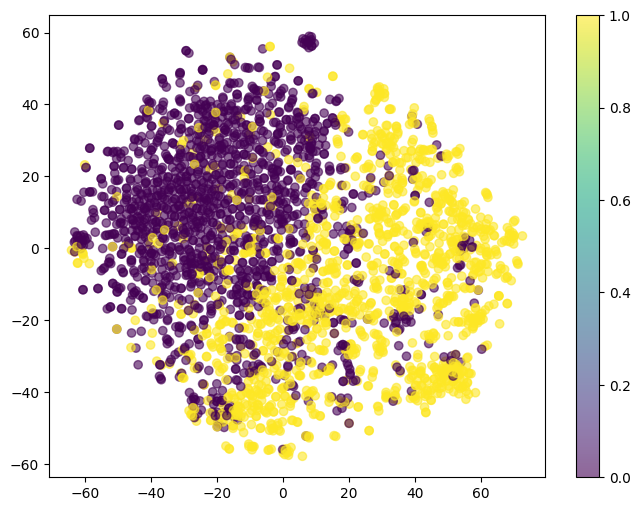

In [43]:
X_vis = TSNE(n_components=2, random_state=42).fit_transform(embeddings[:3000])

plt.figure(figsize=(8,6))
plt.scatter(X_vis[:,0], X_vis[:,1], c=df['label'][:3000], alpha=0.6)
plt.colorbar()
plt.show()

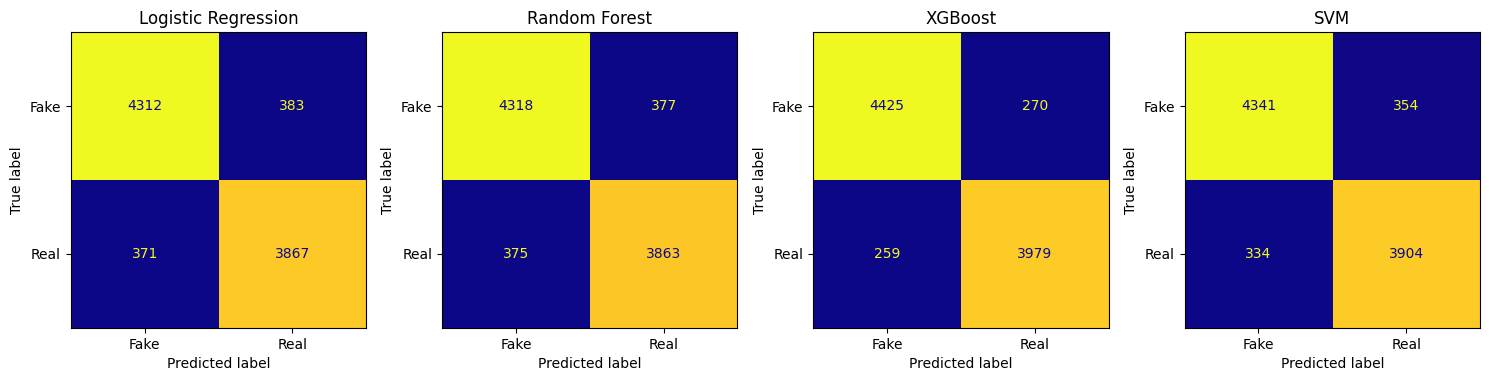

In [44]:
models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb,
    "SVM":svm
}

fig, axes = plt.subplots(1, len(models), figsize=(15,5))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Fake', 'Real']
    )

    disp.plot(ax=ax, cmap='plasma', colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()